In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('data/raw/train.csv')

# Inspect it
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

Matplotlib is building the font cache; this may take a moment.


(913000, 4)
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10
<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB
None
               store           item          sales
count  913000.000000  913000.000000  913000.000000
mean        5.500000      25.500000      52.250287
std         2.872283      14.430878      28.801144
min         1.000000       1.000000       0.000000
25%         3.000000      13.000000      30.000000
50%         5.500000      25.500000      47.000000
75%         8.000000      38.000000      70.000000
max      

Unique stores: 10
Unique items: 50


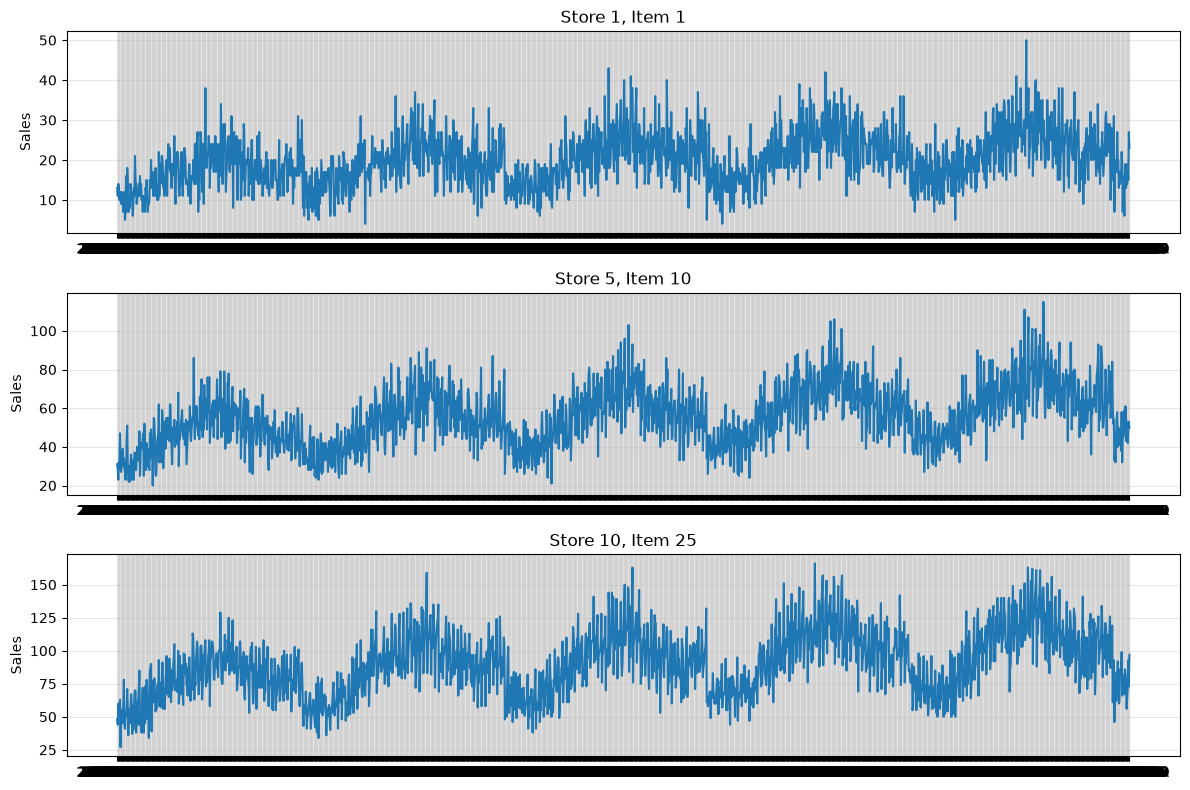

In [2]:
# Check uniqueness
print(f"Unique stores: {df['store'].nunique()}")
print(f"Unique items: {df['item'].nunique()}")

# Pick 3 representative (store, item) pairs
selected = [(1, 1), (5, 10), (10, 25)]

# Plot sales over time
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for idx, (store, item) in enumerate(selected):
    subset = df[(df['store'] == store) & (df['item'] == item)].sort_values('date')
    axes[idx].plot(subset['date'], subset['sales'], linewidth=1.5)
    axes[idx].set_title(f'Store {store}, Item {item}')
    axes[idx].set_ylabel('Sales')
    axes[idx].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
# Stats per store-item combo
stats_per_sku = df.groupby(['store', 'item'])['sales'].agg(
    ['mean', 'std', 'min', 'max']
).reset_index()
stats_per_sku.columns = ['store', 'item', 'mean_demand', 'std_demand', 'min_demand', 'max_demand']

print(stats_per_sku.head(10))

# Create processed folder and save
import os
os.makedirs('data/processed', exist_ok=True)
stats_per_sku.to_csv('data/processed/sku_statistics.csv', index=False)
print("Saved sku_statistics.csv")

   store  item  mean_demand  std_demand  min_demand  max_demand
0      1     1    19.971522    6.741022           4          50
1      1     2    53.148959   15.005779          13         115
2      1     3    33.208105   10.072529           8          70
3      1     4    19.956188    6.640618           4          43
4      1     5    16.612815    5.672102           3          37
5      1     6    53.060789   14.826416          17         104
6      1     7    52.783680   15.073838          14         115
7      1     8    69.472070   18.751980          24         137
8      1     9    46.504929   13.247496          14          94
9      1    10    66.354326   18.283007          16         131
✓ Saved sku_statistics.csv


In [4]:
print("\n=== EDA SUMMARY ===")
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Stores: {df['store'].nunique()}, Items: {df['item'].nunique()}")
print(f"Total SKU combinations: {df['store'].nunique() * df['item'].nunique()}")
print(f"Mean daily sales: {df['sales'].mean():.2f}")
print(f"Std dev: {df['sales'].std():.2f}")


=== EDA SUMMARY ===
Dataset shape: (913000, 4)
Date range: 2013-01-01 to 2017-12-31
Stores: 10, Items: 50
Total SKU combinations: 500
Mean daily sales: 52.25
Std dev: 28.80
